Using device: cuda
Training samples: 60,000
Testing samples: 10,000
--------------------------------------------------
Epoch [1/5] | Training Loss: 0.3328
Epoch [2/5] | Training Loss: 0.1354
Epoch [3/5] | Training Loss: 0.0946
Epoch [4/5] | Training Loss: 0.0718
Epoch [5/5] | Training Loss: 0.0562
--------------------------------------------------
Test Accuracy: 97.60%
Model saved to: mnist_model.pth
--------------------------------------------------
Sample Index: 7
Actual Label: 9
Predicted Label: 9


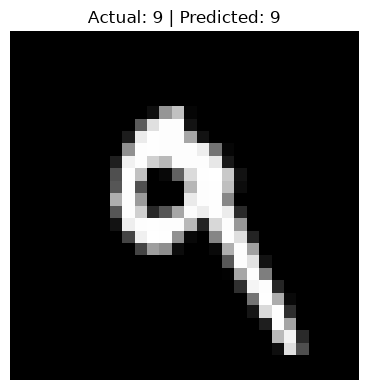

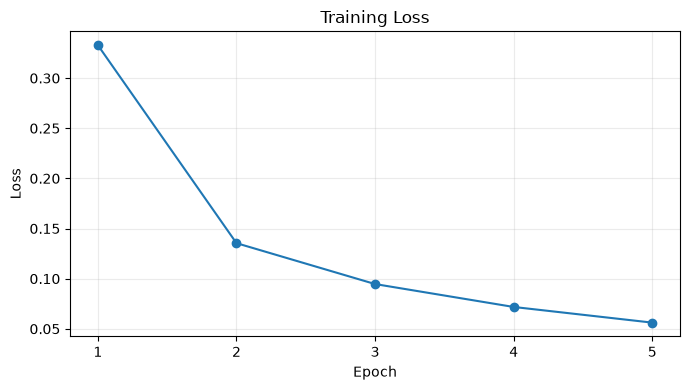

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from pathlib import Path


random_seed = 42
batch_size = 64
learning_rate = 1e-3
epochs = 5

image_size = 28
input_size = image_size * image_size
hidden_size_1 = 128
hidden_size_2 = 64
num_classes = 10

data_dir = Path("data")
model_path = Path("mnist_model.pth")

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

torch.manual_seed(random_seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(random_seed)


transform = transforms.ToTensor()

train_dataset = MNIST(root=data_dir, train=True, download=True, transform=transform)

test_dataset = MNIST(root=data_dir, train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


class DigitModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size_1),
            nn.ReLU(),
            nn.Linear(hidden_size_1, hidden_size_2),
            nn.ReLU(),
            nn.Linear(hidden_size_2, num_classes)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.network(x)


def train_model(model, loader, criterion, optimizer, epochs):
    model.train()
    training_losses = []

    for epoch in range(epochs):
        running_loss = 0.0

        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(loader)
        training_losses.append(epoch_loss)

        print(
            f"Epoch [{epoch + 1}/{epochs}] "
            f"| Training Loss: {epoch_loss:.4f}"
        )

    return training_losses


def evaluate_model(model, loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    return 100.0 * correct / total


def predict(model, image):
    model.eval()

    image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        prediction = outputs.argmax(dim=1).item()

    return prediction


def main():

    print(f"Using device: {device}")
    print(f"Training samples: {len(train_dataset):,}")
    print(f"Testing samples: {len(test_dataset):,}")
    print("-" * 50)

    model = DigitModel().to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    training_losses = train_model(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        epochs=epochs
    )

    print("-" * 50)

    accuracy = evaluate_model(model=model, loader=test_loader)

    print(f"Test Accuracy: {accuracy:.2f}%")

    torch.save(model.state_dict(), model_path)

    print(f"Model saved to: {model_path}")

    sample_index = 7
    sample_image, actual_label = test_dataset[sample_index]

    predicted_label = predict(model, sample_image)

    print("-" * 50)
    print(f"Sample Index: {sample_index}")
    print(f"Actual Label: {actual_label}")
    print(f"Predicted Label: {predicted_label}")

    plt.figure(figsize=(4, 4))
    plt.imshow(sample_image.squeeze(), cmap="gray")
    plt.title(f"Actual: {actual_label} | Predicted: {predicted_label}")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(range(1, epochs + 1), training_losses, marker="o")
    plt.title("Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.xticks(range(1, epochs + 1))
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()